In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Import thư viện thành công!")
print("RANDOM_STATE =", RANDOM_STATE)
print("TEST_SIZE =", TEST_SIZE)

Import thư viện thành công!
RANDOM_STATE = 42
TEST_SIZE = 0.2


In [2]:
DATA_PATH = Path("train.csv")

PROCESSED_DIR = Path("data/processed")
FIGURE_DIR = Path("figures")
MODEL_DIR = Path("models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("File tồn tại:", DATA_PATH.exists())
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("MODEL_DIR:", MODEL_DIR)

DATA_PATH: train.csv
File tồn tại: True
PROCESSED_DIR: data\processed
FIGURE_DIR: figures
MODEL_DIR: models


In [3]:
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("THÔNG TIN DATASET")
print("=" * 60)

print("Số mẫu:", df.shape[0])
print("Số cột:", df.shape[1])
print("Số feature:", df.shape[1] - 1)
print("Target: SalePrice")

display(df.head())

THÔNG TIN DATASET
Số mẫu: 1460
Số cột: 81
Số feature: 80
Target: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print("PHÂN BỐ KIỂU DỮ LIỆU")
print("=" * 60)

dtype_table = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str)
})

display(dtype_table)

print("\nSố lượng theo kiểu dữ liệu:")
print(df.dtypes.value_counts())

PHÂN BỐ KIỂU DỮ LIỆU


,Data_Type
Id,int64
MSSubClass,int64
MSZoning,str
LotFrontage,float64
LotArea,int64
Street,str
Alley,str
LotShape,str
LandContour,str
Utilities,str



Số lượng theo kiểu dữ liệu:
str        43
int64      35
float64     3
Name: count, dtype: int64


In [5]:
print("THỐNG KÊ MÔ TẢ SALEPRICE")
print("=" * 60)

display(df["SalePrice"].describe().to_frame())

print("Median SalePrice:", df["SalePrice"].median())
print("Missing SalePrice:", df["SalePrice"].isna().sum())

THỐNG KÊ MÔ TẢ SALEPRICE


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


Median SalePrice: 163000.0
Missing SalePrice: 0


In [6]:
duplicate_count = df.duplicated().sum()

print("Số dòng trùng lặp:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Đã loại bỏ các dòng trùng lặp.")
else:
    print("Dataset không có dòng trùng lặp.")

Số dòng trùng lặp: 0
Dataset không có dòng trùng lặp.


In [7]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent
})

missing_table = (
    missing_table[missing_table["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

print("Số cột có missing value:", len(missing_table))

display(missing_table.round(2))

Số cột có missing value: 19


,Missing_Count,Missing_Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


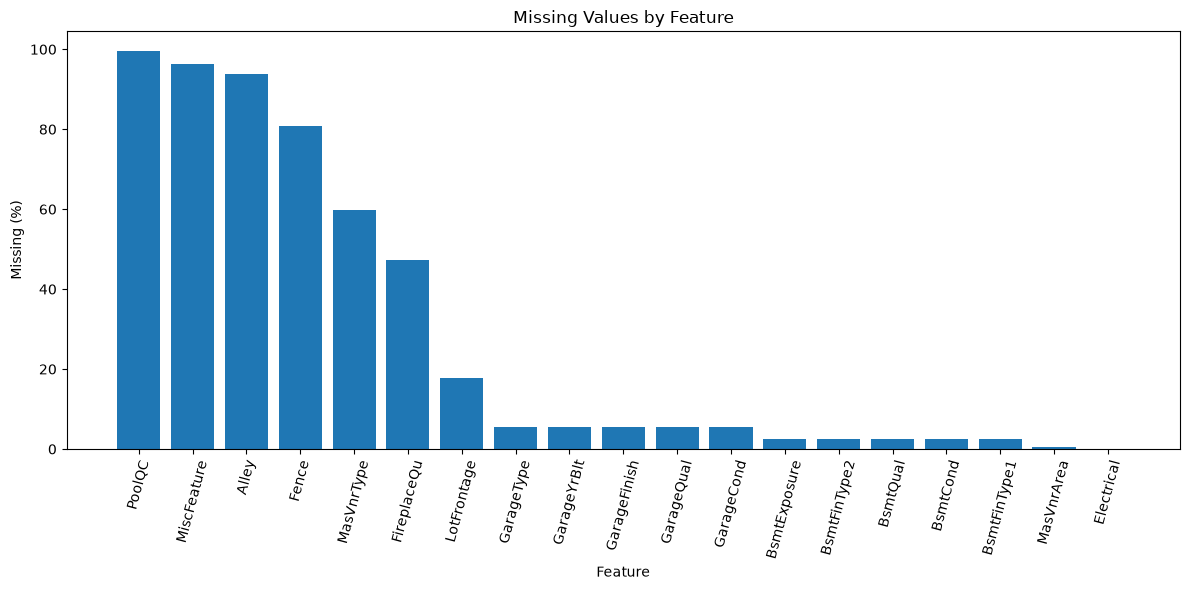

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(
    missing_table.index,
    missing_table["Missing_Percent"]
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing (%)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "missing_values.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

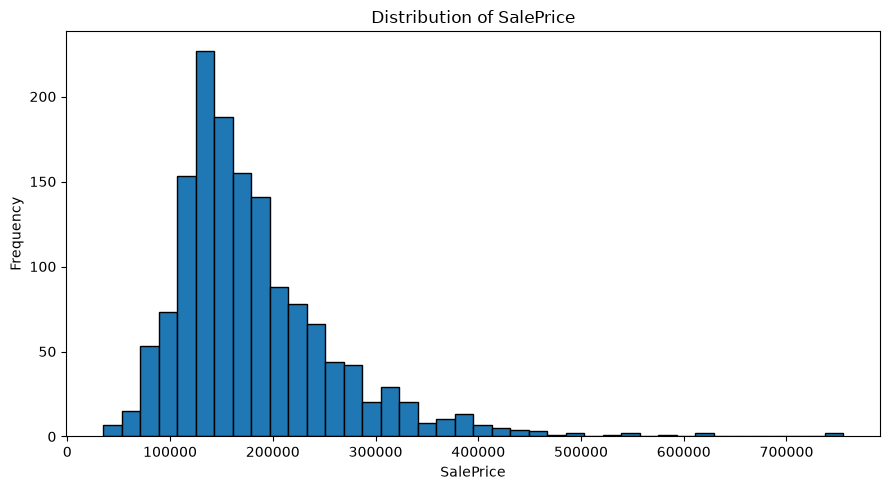

Skewness của SalePrice: 1.8829


In [9]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["SalePrice"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "saleprice_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Skewness của SalePrice:",
    round(df["SalePrice"].skew(), 4)
)

In [10]:
df["log_SalePrice"] = np.log1p(df["SalePrice"])

print(
    "Skewness trước log:",
    round(df["SalePrice"].skew(), 4)
)

print(
    "Skewness sau log:",
    round(df["log_SalePrice"].skew(), 4)
)

Skewness trước log: 1.8829
Skewness sau log: 0.1213


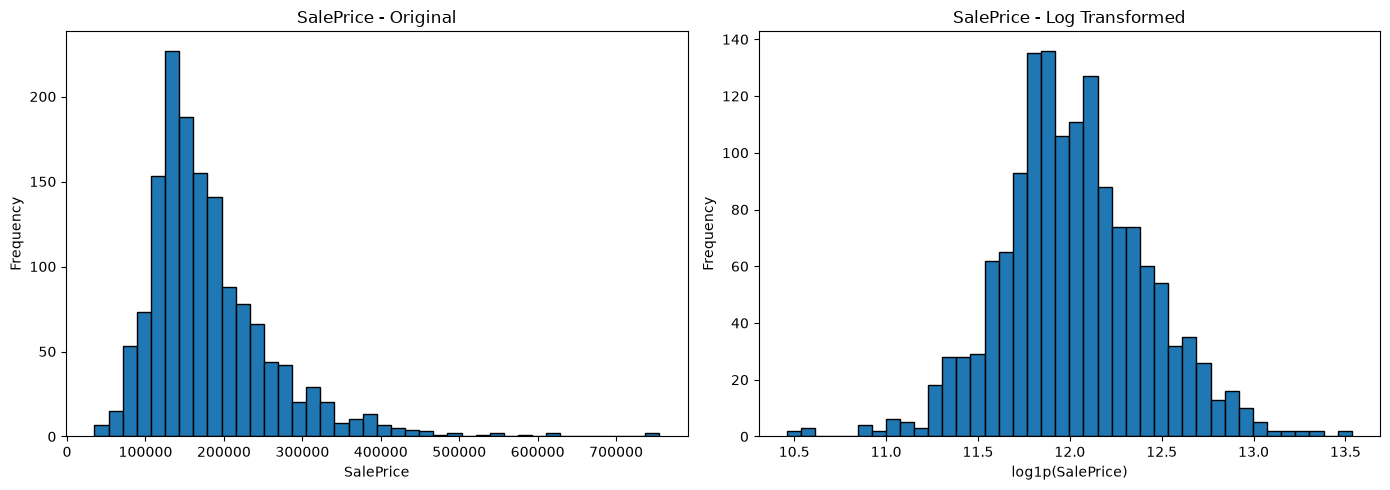

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["SalePrice"],
    bins=40,
    edgecolor="black"
)

axes[0].set_title("SalePrice - Original")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")


axes[1].hist(
    df["log_SalePrice"],
    bins=40,
    edgecolor="black"
)

axes[1].set_title("SalePrice - Log Transformed")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "saleprice_before_after_log.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

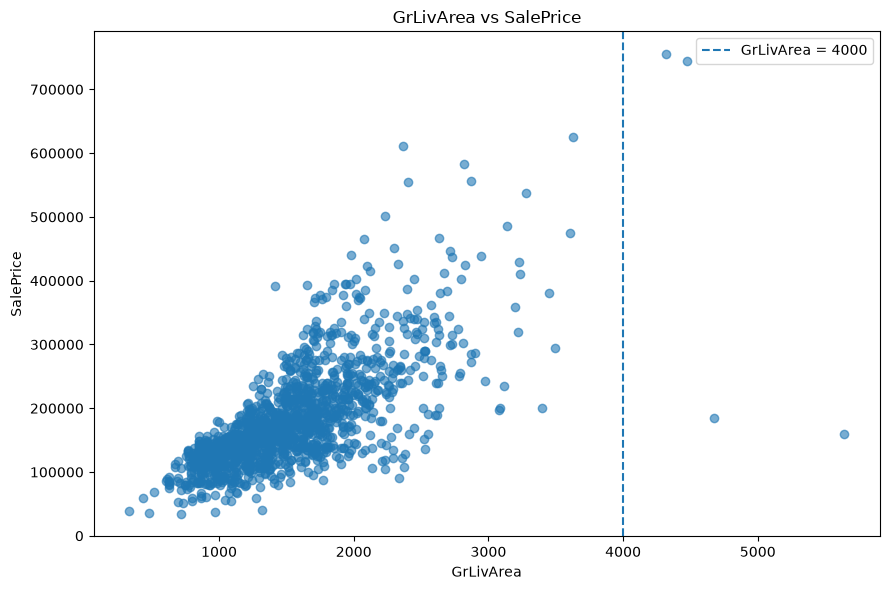

In [12]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.6
)

plt.axvline(
    x=4000,
    linestyle="--",
    label="GrLivArea = 4000"
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "grlivarea_outliers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [13]:
outlier_table = df.loc[
    df["GrLivArea"] > 4000,
    ["Id", "GrLivArea", "SalePrice"]
].sort_values("GrLivArea")

print("Các mẫu có GrLivArea > 4000:")
display(outlier_table)

Các mẫu có GrLivArea > 4000:


,Id,GrLivArea,SalePrice
691,692,4316,755000
1182,1183,4476,745000
523,524,4676,184750
1298,1299,5642,160000


In [14]:
outlier_condition = (
    (df["GrLivArea"] > 4000)
    & (df["SalePrice"] < 300000)
)

print("Số outlier cần loại:", outlier_condition.sum())

display(
    df.loc[
        outlier_condition,
        ["Id", "GrLivArea", "SalePrice"]
    ]
)

df = df.loc[~outlier_condition].copy()
df.reset_index(drop=True, inplace=True)

print("Số mẫu sau khi loại outlier:", len(df))

Số outlier cần loại: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Số mẫu sau khi loại outlier: 1458


In [15]:
# Tổng diện tích
df["TotalSF"] = (
    df["TotalBsmtSF"].fillna(0)
    + df["1stFlrSF"].fillna(0)
    + df["2ndFlrSF"].fillna(0)
)

# Tuổi nhà tại thời điểm bán
df["HouseAge"] = (
    df["YrSold"] - df["YearBuilt"]
)

# Khoảng thời gian từ lần sửa gần nhất đến lúc bán
df["RemodAge"] = (
    df["YrSold"] - df["YearRemodAdd"]
)

# Tổng số phòng tắm quy đổi
df["TotalBath"] = (
    df["FullBath"].fillna(0)
    + 0.5 * df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5 * df["BsmtHalfBath"].fillna(0)
)

new_features = [
    "TotalSF",
    "HouseAge",
    "RemodAge",
    "TotalBath"
]

print("Các feature mới:")
print(new_features)

display(df[new_features].head())

Các feature mới:
['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath']


,TotalSF,HouseAge,RemodAge,TotalBath
0,2566,5,5,3.5
1,2524,31,31,2.5
2,2706,7,6,3.5
3,2473,91,36,2.0
4,3343,8,8,3.5


In [16]:
none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

print("Đã xử lý missing mang ý nghĩa 'không có'.")

Đã xử lý missing mang ý nghĩa 'không có'.


In [17]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

encoded_cols = []

for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_map)
        encoded_cols.append(col)

print("Các cột đã Ordinal Encode:")
print(encoded_cols)

Các cột đã Ordinal Encode:
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']


In [18]:
y = df["log_SalePrice"].copy()

X = df.drop(
    columns=[
        "Id",
        "SalePrice",
        "log_SalePrice"
    ],
    errors="ignore"
).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Số feature trước preprocessing:", X.shape[1])

X shape: (1458, 83)
y shape: (1458,)
Số feature trước preprocessing: 83


In [19]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1166, 83)
X_test : (292, 83)
y_train: (1166,)
y_test : (292,)


In [20]:
numeric_features = (
    X_train_raw
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train_raw
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print(
    "Tổng:",
    len(numeric_features)
    + len(categorical_features)
)

Numeric features: 50
Categorical features: 33
Tổng: 83


In [21]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            onehot
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Đã tạo preprocessing pipeline.")

Đã tạo preprocessing pipeline.


In [22]:
X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)

print("Preprocessing hoàn tất.")

print(
    "X_train sau preprocessing:",
    X_train_processed.shape
)

print(
    "X_test sau preprocessing:",
    X_test_processed.shape
)

Preprocessing hoàn tất.
X_train sau preprocessing: (1166, 262)
X_test sau preprocessing: (292, 262)


In [23]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]

print(
    "Số feature trước preprocessing:",
    X_train_raw.shape[1]
)

print(
    "Số feature sau preprocessing:",
    len(feature_names)
)

print("\n20 feature đầu:")
print(feature_names[:20])

Số feature trước preprocessing: 83
Số feature sau preprocessing: 262

20 feature đầu:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF']


In [24]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("X_train_processed:")
print(X_train_processed.shape)

display(X_train_processed.head())

X_train_processed:
(1166, 262)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodAge,TotalBath,...,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_Fin,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.857409,0.017096,-0.207656,-0.781412,0.372581,-0.459933,-1.346989,-0.580392,-0.665758,2.614323,-0.538915,0.122435,1.103191,-0.298095,-0.375110,0.635096,-1.165102,0.419702,-0.791478,-0.11135,-0.391102,1.098561,-0.250902,-1.014654,-0.761581,0.148858,-0.226848,-0.755676,-0.950349,-0.951228,-1.004431,-0.887749,-1.017111,-0.822948,0.267373,0.27098,1.206124,-0.709291,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.121665,1.657667,0.091628,0.532180,1.455425,-0.272807,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.078786,-0.503746,-0.260606,-0.053675,1.268311,0.731291,0.447637,-0.580392,1.078678,-0.223946,0.591255,0.122435,-1.027807,-0.298095,0.544004,-0.608225,-0.128072,-0.983472,0.972939,-0.11135,0.118277,-0.813263,-0.250902,0.783350,1.216154,0.148858,-0.226848,-0.755676,0.294715,0.600005,0.656798,0.615384,0.318420,-0.421258,0.267373,0.27098,-0.747843,-0.113220,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.494003,0.904417,-0.242249,-0.690817,-0.389854,0.368509,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.857409,-0.030253,-0.174738,-0.781412,0.372581,-0.029769,-0.716444,-0.137330,-0.665758,-0.223946,-0.538915,0.122435,0.885931,-0.298095,-0.867412,-0.118139,-1.165102,-0.430376,-0.791478,-0.11135,-1.009492,1.098561,-0.250902,-1.014654,-0.761581,0.148858,-0.226848,-0.755676,-0.950349,-0.951228,-1.004431,-0.219690,0.318420,2.016904,0.267373,0.27098,-0.747843,-0.709291,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,0.623013,0.904417,-0.715887,0.069425,0.775585,-0.272807,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.155263,-0.456397,-0.320515,-0.781412,1.268311,-1.121725,-1.686513,0.888710,-0.665758,-0.223946,0.591255,0.122435,0.287310,-0.298095,-0.894511,-0.772392,0.908958,-0.487593,1.007222,-0.11135,0.508735,1.098561,-0.250902,-1.014654,1.216154,0.148858,-0.226848,0.766117,0.294715,2.151238,0.656798,-1.639316,-1.017111,-1.075171,0.267373,0.27098,-0.747843,-0.709291,4.042204,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.121665,-0.602083,-0.075311,1.094098,1.649665,0.368509,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0

In [25]:
print("=" * 60)
print("KIỂM TRA DỮ LIỆU SAU PREPROCESSING")
print("=" * 60)

print(
    "Missing X_train:",
    X_train_processed.isna().sum().sum()
)

print(
    "Missing X_test:",
    X_test_processed.isna().sum().sum()
)

print(
    "Infinity X_train:",
    np.isinf(
        X_train_processed.to_numpy()
    ).sum()
)

print(
    "Infinity X_test:",
    np.isinf(
        X_test_processed.to_numpy()
    ).sum()
)

KIỂM TRA DỮ LIỆU SAU PREPROCESSING
Missing X_train: 0
Missing X_test: 0
Infinity X_train: 0
Infinity X_test: 0


In [26]:
X_train_processed = X_train_processed.reset_index(drop=True)
X_test_processed = X_test_processed.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Reset index hoàn tất.")

Reset index hoàn tất.


In [27]:
X_train_processed.to_csv(
    PROCESSED_DIR / "X_train.csv",
    index=False
)

X_test_processed.to_csv(
    PROCESSED_DIR / "X_test.csv",
    index=False
)

y_train.to_frame(
    name="log_SalePrice"
).to_csv(
    PROCESSED_DIR / "y_train.csv",
    index=False
)

y_test.to_frame(
    name="log_SalePrice"
).to_csv(
    PROCESSED_DIR / "y_test.csv",
    index=False
)

pd.DataFrame({
    "feature": feature_names
}).to_csv(
    PROCESSED_DIR / "feature_names.csv",
    index=False
)

print("Đã lưu:")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")
print("- feature_names.csv")

Đã lưu:
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv
- feature_names.csv


In [28]:
joblib.dump(
    preprocessor,
    MODEL_DIR / "preprocessor.pkl"
)

print("Đã lưu models/preprocessor.pkl")

Đã lưu models/preprocessor.pkl
